In [107]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import norm
import os
import pandas as pd

os.makedirs("data", exist_ok=True)

In [108]:
START = "2018-01-01"
END = "2025-12-31"
TRADING_DAYS = 252

tickers = {
    "S&P500": "^GSPC",
    "EUROSTOXX": "^STOXX50E",
    "EUR_BOND": "^TNX",  
    "EURUSD": "EURUSD=X",
    "GOLD": "GC=F"
}

weighting = {
    "Stocks": 0.4, 
    "Bonds": 0.3, 
    "Currencies": 0.2, 
    "Commodities": 0.1}


[*********************100%***********************]  5 of 5 completed

              S&P500    EUROSTOXX     EUR_BOND       EURUSD   GOLD
Date                                                              
2025-12-23  1.176595  4482.799805  6909.790039  5749.279785  4.169
2025-12-24  1.179551  4480.600098  6932.049805  5749.279785  4.136
2025-12-26  1.178536  4529.100098  6929.939941  5749.279785  4.136
2025-12-29  1.177274  4325.100098  6905.740234  5751.709961  4.116
2025-12-30  1.177288  4370.100098  6896.240234  5796.220215  4.130



/var/folders/6l/kcpg27zj1q37ycq_x5rxd6940000gn/T/ipykernel_28837/1427908486.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True) # if nan, fill with previous value


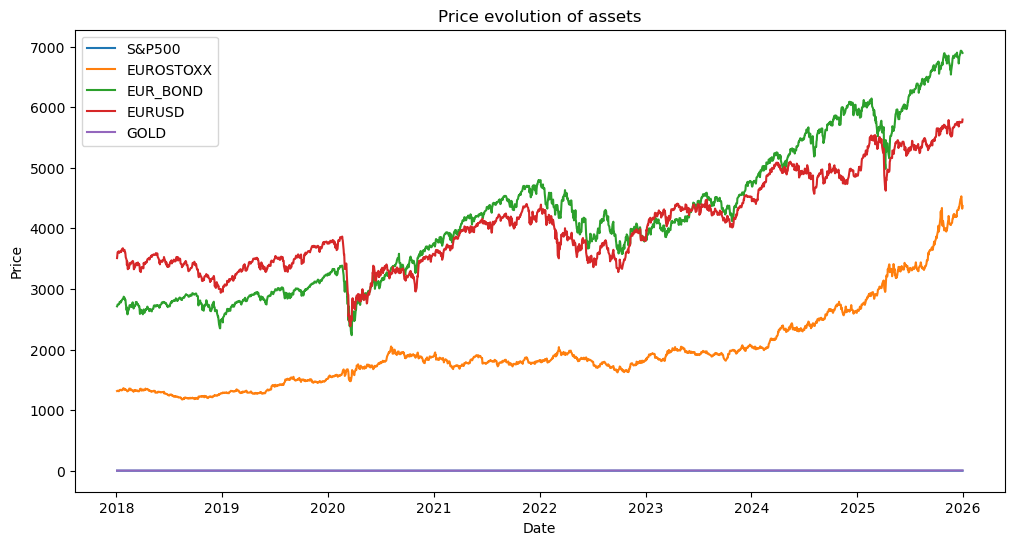

In [109]:
data = yf.download(list(tickers.values()), start=START, end=END)["Close"]
data.columns = tickers.keys()

data.fillna(method='ffill', inplace=True) # if nan, fill with previous value
#print(data.isna().sum())
data = data.dropna() #remove rows with missing values
print(data.tail())
data.describe();

# plot the price evolution of each asset
plt.figure(figsize=(12, 6))
for col in data.columns:
    plt.plot(data.index, data[col], label=col)
plt.title("Price evolution of assets")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


Daily returns:
              S&P500  EUROSTOXX  EUR_BOND    EURUSD      GOLD
Date                                                         
2018-01-04 -0.004396   0.002431  0.004029  0.016810  0.002452
2018-01-05  0.004864   0.000682  0.007034  0.010858  0.009376
2018-01-08 -0.002600  -0.001288  0.001662  0.002445  0.001615
2018-01-09 -0.005566  -0.005233  0.001303  0.001775  0.026613
2018-01-10 -0.003436   0.004346 -0.001112 -0.003599  0.001571


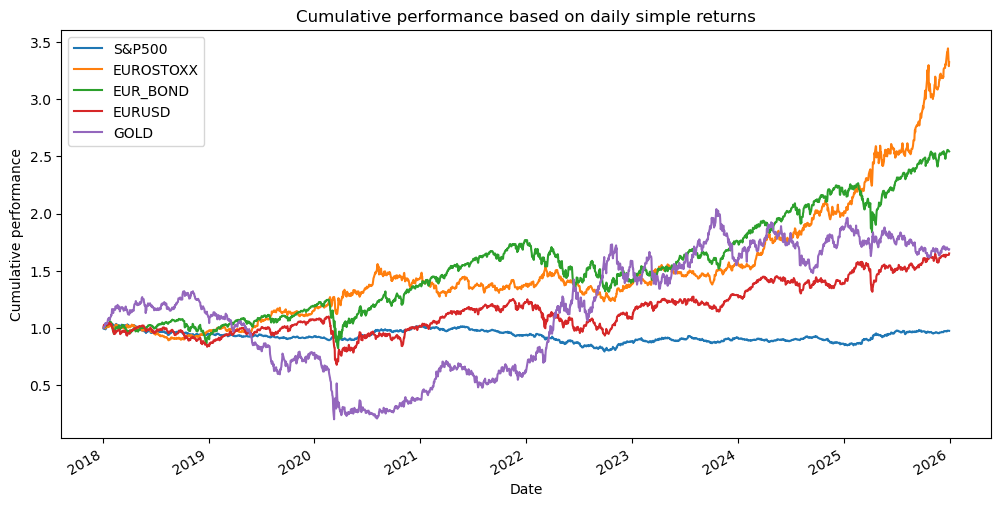

Daily log returns:
              S&P500  EUROSTOXX  EUR_BOND    EURUSD      GOLD
Date                                                         
2018-01-04 -0.004406   0.002428  0.004021  0.016670  0.002449
2018-01-05  0.004852   0.000682  0.007009  0.010799  0.009333
2018-01-08 -0.002603  -0.001288  0.001661  0.002442  0.001614
2018-01-09 -0.005582  -0.005247  0.001302  0.001774  0.026265
2018-01-10 -0.003442   0.004336 -0.001113 -0.003606  0.001570


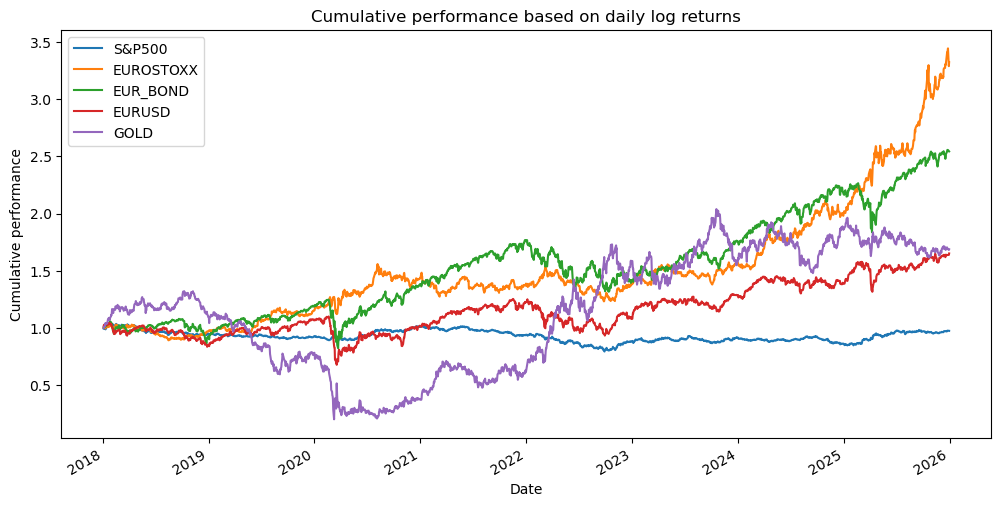

In [110]:
# cumulative from simple returns
simple_returns = data.pct_change().dropna() # simple returns
print("Daily returns:")
print(simple_returns.head())

cum_assets_simple = (1 + simple_returns).cumprod()
cum_assets_simple.plot(figsize=(12, 6))
plt.title("Cumulative performance based on daily simple returns")
plt.xlabel("Date")
plt.ylabel("Cumulative performance")
plt.legend()
plt.show()


# cumulative from daily log returns
log_returns = np.log(data / data.shift(1)).dropna() # log returns
print("Daily log returns:")
print(log_returns.head())

cum_assets_log = np.exp(log_returns.cumsum())
cum_assets_log.plot(figsize=(12, 6))
plt.title("Cumulative performance based on daily log returns")
plt.xlabel("Date")
plt.ylabel("Cumulative performance")
plt.legend()
plt.show()


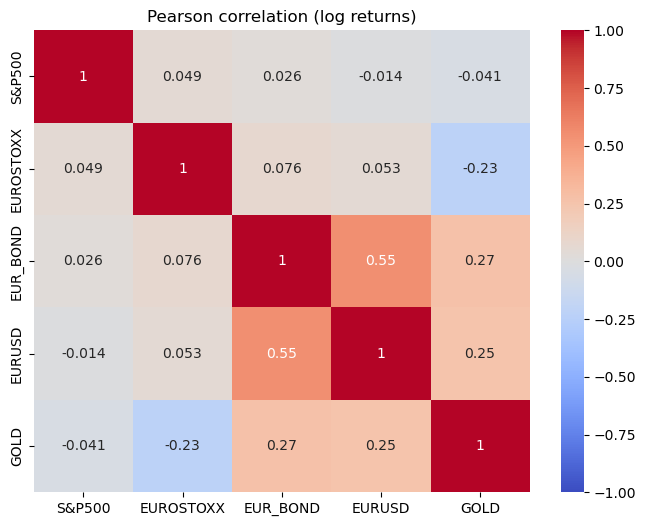

In [111]:
# correlation matrices based on log returns
corr_pearson = log_returns.corr()
corr_spearman = log_returns.corr(method="spearman")

# heatmap Pearson
plt.figure(figsize=(8, 6))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson correlation (log returns)")
plt.show()

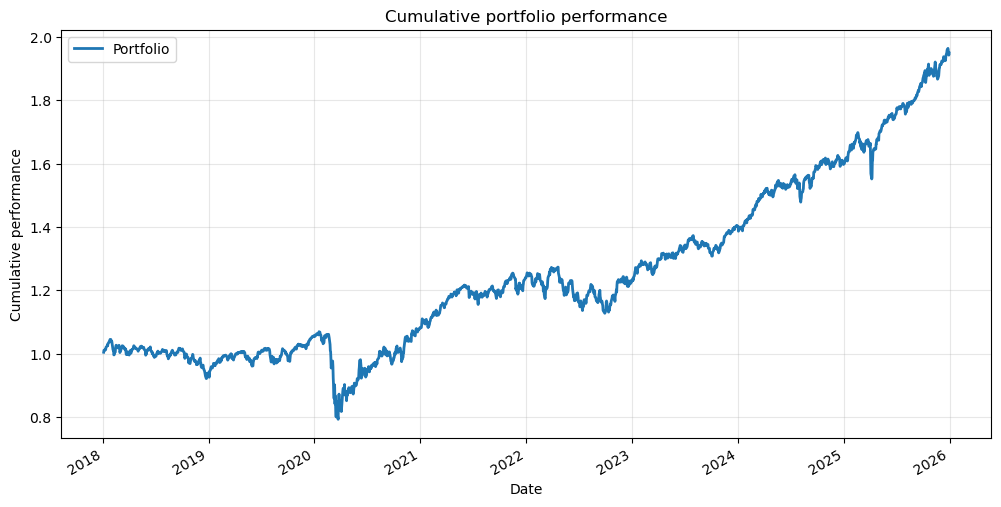

In [112]:
portfolio = {
    'Stocks': ['S&P500', 'EUROSTOXX'],
    'Bonds': ['EUR_BOND'],
    'Currencies': ['EURUSD'],
    'Commodities': ['GOLD']
}

weights = {}
for cls, assets in portfolio.items():
    for asset in assets:
        weights[asset] = weighting[cls] / len(assets)
weights = pd.Series(weights) # convertion in serties for easier manipulation
#print("Poids par actif :\n", weights)
#print("Total poids:", weights.sum())

# daily portfolio returns and cumulative portfolio performance
#print(log_returns)
#print(log_returns[weights.index])
#print(log_returns * weights)

#print(weights.sum())
port_returns = (log_returns[weights.index] * weights).sum(axis=1) # daily portfolio returns
port_cum = np.exp(port_returns.cumsum()) #@ cumulative portfolio performance
#print(port_cum)

plt.figure(figsize=(12, 6))
port_cum.plot(label='Portfolio', linewidth=2)
plt.title("Cumulative portfolio performance")
plt.xlabel("Date")
plt.ylabel("Cumulative performance")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [113]:
# save data and results
data.to_csv("data/prices.csv")
log_returns.to_csv("data/returns_log.csv")
port_returns.to_frame("Portfolio").to_csv("data/portfolio_returns_log.csv")
weights.to_csv("data/weights.csv",  index=True)

print("Saved")


Saved
